In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve
)

import joblib
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42,
    test_size=0.2
)

## Recreate SMOTE pipeline

In [5]:
best_model = joblib.load("../models/best_smote_model.pkl")

# Cross Validation

In [6]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [7]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [8]:
cv_results = cross_validate(
    best_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [9]:
pd.DataFrame(cv_results).mean()

fit_time          0.458052
score_time        0.071865
test_accuracy     0.748860
test_precision    0.518277
test_recall       0.787058
test_f1           0.624953
test_roc_auc      0.844194
dtype: float64

# ROC curve

In [10]:
best_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](28,)","['gender','SeniorCitizen','Partner',...,'StreamingUser','AutoPayment', 'PremiumCustomer']"
n_features_in_,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [11]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [12]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

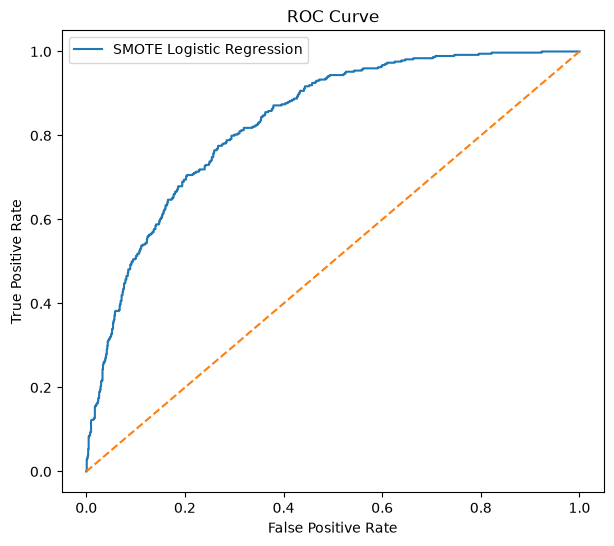

In [13]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="SMOTE Logistic Regression")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Precision - Recall Curve

In [14]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

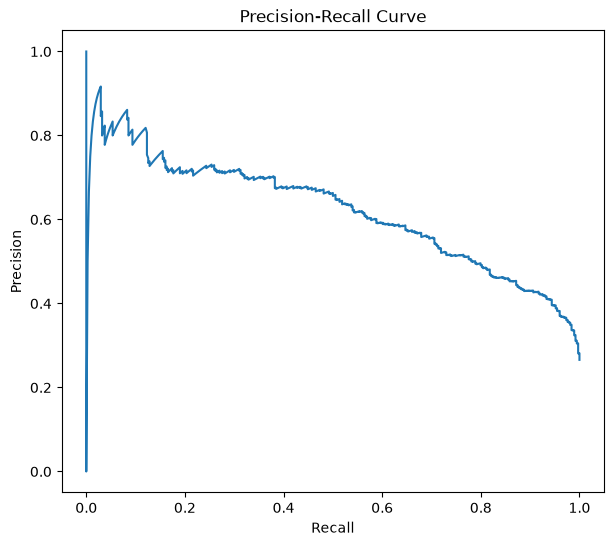

In [15]:
plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

# Threshold Tuning

In [16]:
thresholds = np.arange(0.1,0.91,0.05)

threshold_results = []

In [17]:
for threshold in thresholds:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            predictions
        ),

        "Recall": recall_score(
            y_test,
            predictions
        ),

        "F1": f1_score(
            y_test,
            predictions
        )

    })

In [18]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.352546,0.981283,0.518728
1,0.15,0.377101,0.959893,0.541478
2,0.20,0.395323,0.949198,0.558176
3,0.25,0.411072,0.933155,0.570728
4,0.30,0.427854,0.911765,0.582408
5,0.35,0.440108,0.874332,0.585497
6,0.40,0.458453,0.855615,0.597015
7,0.45,0.481013,0.812834,0.604374
8,0.50,0.504333,0.778075,0.611987
9,0.55,0.522073,0.727273,0.607821


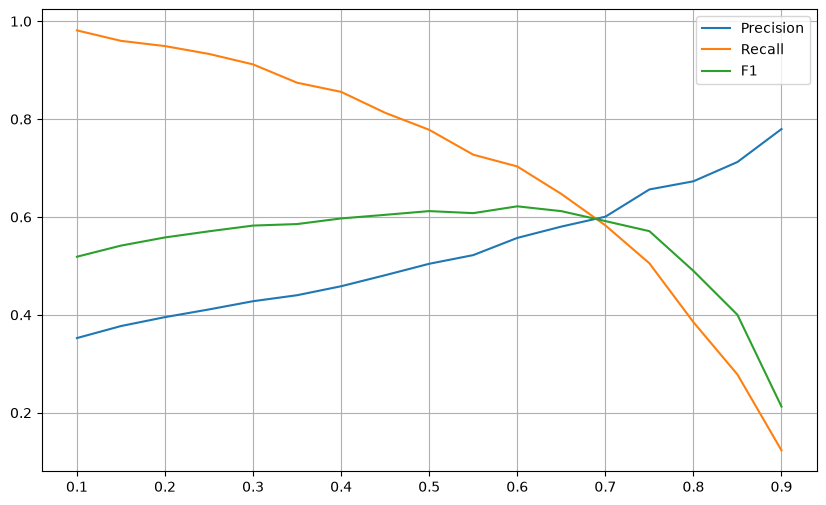

In [19]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.legend()

plt.grid()

plt.show()

# Choosing best threshold

In [20]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

print(best_threshold)

0.6000000000000002


In [21]:
final_predictions = (
    y_prob >= best_threshold
).astype(int)

# Summary

- Evaluated model stability using 5-fold Stratified Cross Validation.
- Generated ROC and Precision-Recall curves.
- Explored multiple decision thresholds instead of relying on the default value of 0.5.
- Selected the threshold that maximized the F1-score.
- Prepared the optimized model for comparison with cost-sensitive learning methods.